## Flash Attention
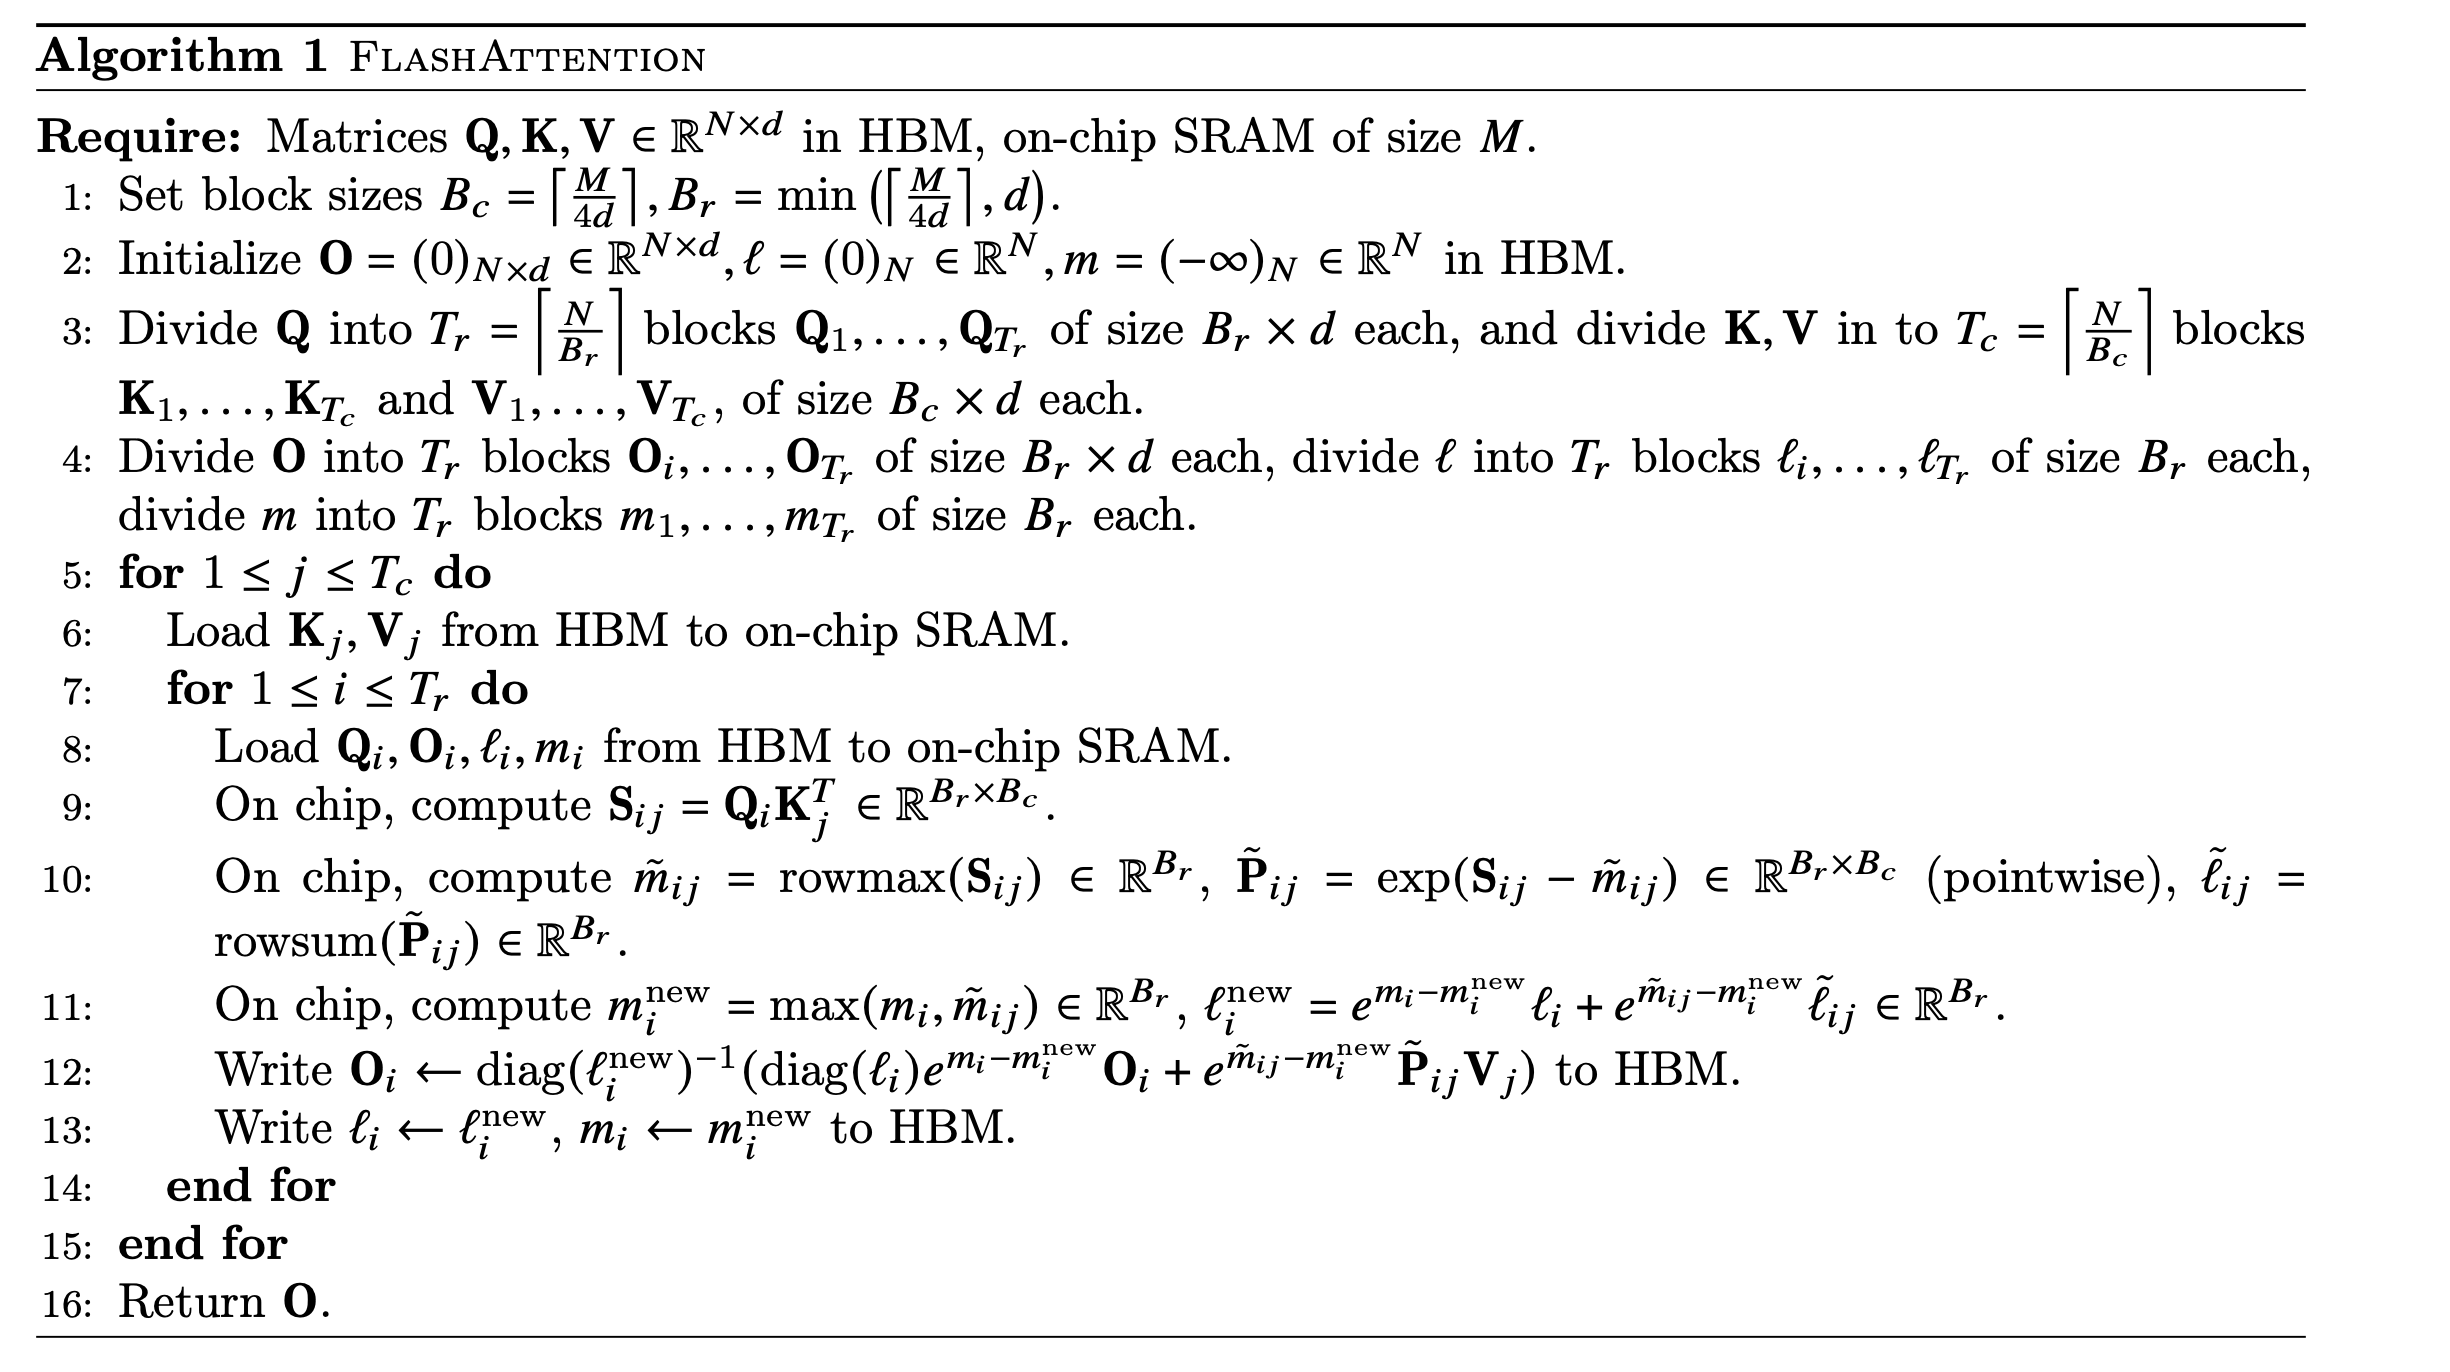

In [28]:
import torch
import math
from einops import rearrange


In [16]:
N = 8 #seq_len
d = 4 #head_dim
M = 32 #SRAM Capacity

Bc = math.ceil(M/(4*d))
Br = min(math.ceil(M / (4 * d)), d)

In [17]:
print(f"Br = {Br}")
print(f"Bc = {Bc}")

Br = 2
Bc = 2


In [18]:
Q = torch.randn(N,d)
K = torch.randn(N, d)
V = torch.randn(N, d)

In [19]:
O = torch.zeros((N, d))
l = torch.zeros(N)
m = torch.full((N,), -float("inf"))

In [20]:
Tr = math.ceil(N / Br)
Tc = math.ceil(N / Bc)
print(f"Tr: {Tr}")
print(f"Tc: {Tc}")

Tr: 4
Tc: 4


In [34]:
Q_blocks = torch.split(Q, Br, dim=0) #(Br, d)
V_blocks = torch.split(V, Bc, dim=0) #(Bc, d)
K_blocks = torch.split(K, Bc, dim=0) #(Bc, d)

O_blocks = list(torch.split(O, Br, dim=0)) #(Br, d)
l_blocks = list(torch.split(l, Br, dim=0)) #(Br,)
m_blocks = list(torch.split(m, Br, dim=0)) #(Br,)


$\tilde{m} = \max_{j} (S_{ij})$

In [35]:
for Kj, Vj in zip(K_blocks, V_blocks):
    for i, (Qi, Oi, li, mi) in enumerate(zip(Q_blocks, O_blocks, l_blocks, m_blocks)):
        # line 9
        Sij = Qi @ Kj.T #(Br, Bc)
        # line 10
        m_tilde = Sij.max(dim=1).values #(max along the rows)
        P_tilde = torch.exp(Sij - rearrange(m_tilde, 'br -> br 1'))
        l_tilde = P_tilde.sum(dim=1)
        
        # line 11
        m_new = torch.maximum(mi, m_tilde)
        alpha = torch.exp(mi - m_new)
        beta = torch.exp(m_tilde - m_new)
        l_new = alpha * li + beta * l_tilde

        # line 12
        PV = P_tilde @ Vj
        alpha = rearrange(alpha, 'br-> br 1')
        beta = rearrange(beta, 'br -> br 1')
        li = rearrange(li, 'br -> br 1')
        l_new = rearrange(l_new, 'br -> br 1')
        O_new = (li*alpha*Oi + beta* PV)/l_new

        O_blocks[i] = O_new
        l_blocks[i] = l_new.squeeze(1)
        m_blocks[i] = m_new

O = torch.cat(O_blocks, dim=0)


In [36]:
scores = Q @ K.T
P = torch.softmax(scores, dim=-1)
expected = P @ V

print("FlashAttention Output:")
print(O)

print("\nVanilla Attention Output:")
print(expected)

print("\nAll Close:", torch.allclose(O, expected, atol=1e-5))
print("Max Error:", (O - expected).abs().max())

FlashAttention Output:
tensor([[ 1.0772,  1.7937,  0.6008,  0.8557],
        [-0.9512,  0.1458,  0.1343,  0.4667],
        [-0.6506,  0.5710, -1.4275, -1.5003],
        [-0.1911,  0.7410, -0.4184, -0.0965],
        [-1.2962,  0.0094,  0.3332,  0.0379],
        [-0.9103,  0.3786, -0.7990, -1.0290],
        [-0.7471, -0.0647,  0.1892,  0.1953],
        [-0.5987,  0.6367,  0.1536,  0.6690]])

Vanilla Attention Output:
tensor([[ 1.0772,  1.7937,  0.6008,  0.8557],
        [-0.9512,  0.1458,  0.1343,  0.4667],
        [-0.6506,  0.5710, -1.4275, -1.5003],
        [-0.1911,  0.7410, -0.4184, -0.0965],
        [-1.2962,  0.0094,  0.3332,  0.0379],
        [-0.9103,  0.3786, -0.7990, -1.0290],
        [-0.7471, -0.0647,  0.1892,  0.1953],
        [-0.5987,  0.6367,  0.1536,  0.6690]])

All Close: True
Max Error: tensor(2.3842e-07)
